In [73]:
import os
import glob
import h5py
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
from IPython.display import display, HTML

from vip_slap2_analysis.voltage.extraction import load_voltage_roi_transform_h5
from vip_slap2_analysis.plotting.plot_session_heatmap import _robust_row_zscore
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.voltage.summary import VoltageSummary
from vip_slap2_analysis.utils.utils import save_figure

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

display(HTML("<style>.container { width:100% !important; }</style>"))
warnings.filterwarnings("default")

In [2]:
%matplotlib notebook

In [3]:
%load_ext autoreload
%autoreload 2

In [81]:
today_str = datetime.today().strftime('%Y-%m-%d')

BASE_PATH = Path(r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics')
SAVE_PATH = Path(r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures')

TARGET_MICE = [
    826031,
]

PARADIGMS = ["change_detection_passive"]
EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]

# Voltage extraction writes files like:
#   voltage_session_traces_dff_robust_f0_trial.h5
# This variant controls the filename suffix. The plotted dataset is SIGNAL below.
TRACE_VARIANT = "dff_robust_f0_trial"
SIGNAL = "dff"      # one of: "raw_f", "f0", "dff"

# Optional direct override. Leave as None to resolve from asset.derived_dir / "voltage".
SESSION_TRACE_H5 = None

In [5]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

process_df = registry.sessions(
    subject_ids=TARGET_MICE,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
    paradigms=PARADIGMS,
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Found {len(assets)} candidate sessions.")
display(process_df)

Found 10 candidate sessions.


,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_id,camera_type,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
0,826031_2026-01-30_15-04-02,826031,2,2026-01-30,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
1,826031_2026-02-01_11-01-50,826031,3,2026-02-01,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
2,826031_2026-02-02_10-23-53,826031,4,2026-02-02,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
3,826031_2026-02-03_14-21-45,826031,5,2026-02-03,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
4,826031_2026-02-04_12-15-34,826031,6,2026-02-04,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
5,826031_2026-02-05_09-28-56,826031,7,2026-02-05,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
6,826031_2026-02-06_10-21-20,826031,8,2026-02-06,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
7,826031_2026-02-10_10-48-51,826031,9,2026-02-10,ASAP7y,NaN,50,250,change_detection_passive,novel,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
8,826031_2026-02-11_12-42-21,826031,10,2026-02-11,ASAP7y,NaN,50,250,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
9,826031_2026-02-12_07-43-37,826031,11,2026-02-12,ASAP7y,NaN,50,250,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN


In [46]:
asset = assets[4]
print(asset.session_id)
print("session_dir:", asset.session_dir)
print("derived_dir:", asset.derived_dir)
print("voltage assets:")
for key, path in asset.get_modality_assets("voltage").items():
    print(f"  {key}: {path}")

826031_2026-02-04_12-15-34
session_dir: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34
derived_dir: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\analysis\derived
voltage assets:
  summary_mat: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34_slap2_2026-02-04_12-15-34\source_extraction\dendriticVoltageExtraction\dendriticVoltageSummary-260625-134608.mat
  trace_h5: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34_slap2_2026-02-04_12-15-34\source_extraction\dendriticVoltageExtraction\dendriticVoltageTraces-260625-134608.h5
  extraction_dir: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\826031_2026-02-04_12-15-34_slap2_2026-02-04_12-15-34\source_extraction\dendriticVoltageExtraction


In [47]:
vs = VoltageSummary(asset.modality_assets['voltage']['summary_mat'])

Inspecting: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-04_12-15-34\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial.h5


<IPython.core.display.Javascript object>


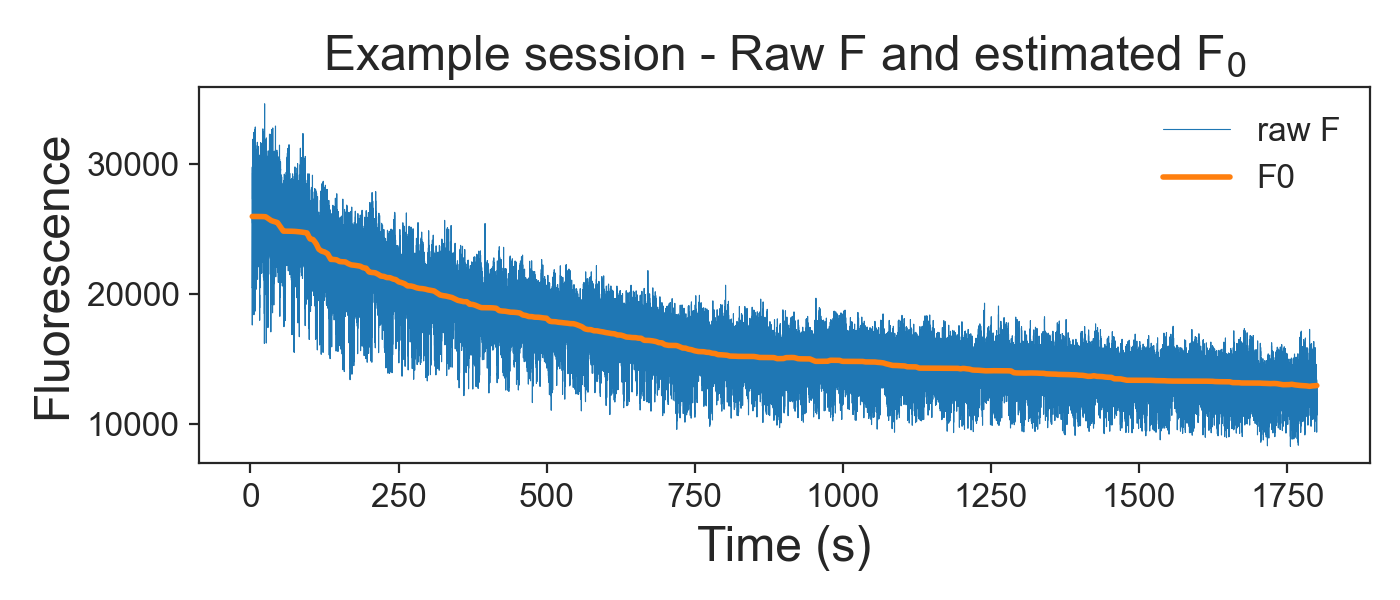

<IPython.core.display.Javascript object>


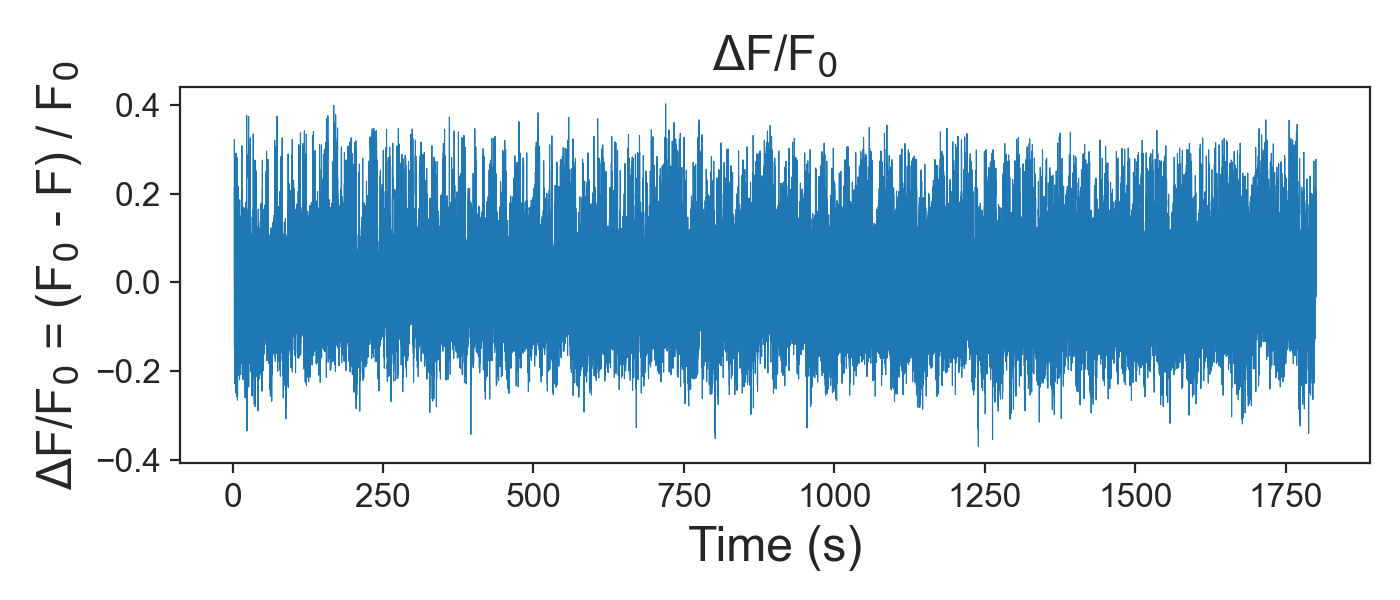

In [85]:
dmd = 1
roi_index = 0
trace_signal = "dff_robust_f0"

session_trace_h5 = asset.derived_dir / 'voltage' / 'voltage_session_traces_dff_robust_f0_trial.h5'
print("Inspecting:", session_trace_h5)

if not session_trace_h5.exists():
    print("Session trace H5 not found. Run voltage extraction first, or use the next cell to compute one ROI on the fly.")
else:
    roi = load_voltage_roi_transform_h5(session_trace_h5, dmd=dmd, roi_index=roi_index)
    t = roi["timebase_sec"]
    raw_f = roi["raw_f"]
    f0 = roi["f0"]
    dff = roi["dff"]
    window = (0,1800)

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
    ax.plot(t[t<=window[1]], raw_f[t<=window[1]], lw=0.4, label="raw F")
    ax.plot(t[t<=window[1]], f0[t<=window[1]], lw=2.0, label="F0")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Fluorescence")
    ax.set_title("Example session - Raw F and estimated F$_{0}$")
    ax.legend(frameon=False,fontsize=12)
    fig.tight_layout()
    filen = 'rawF_F0_example'
    save_figure(fig,os.path.join(SAVE_PATH,filen),formats = ['.pdf','.png'],dpi=300)
    
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
    ax.plot(t[t<=window[1]], dff[t<=window[1]], lw=0.4)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("\u0394F/F$_{0}$ = (F$_{0}$ - F) / F$_{0}$")
    ax.set_title('\u0394F/F$_{0}$')
    fig.tight_layout()
    filen = 'dFF_example'
    save_figure(fig,os.path.join(SAVE_PATH,filen),formats = ['.pdf','.png'],dpi=300)

[23, 9]

In [88]:
dmds = [1,2]

n_rois = vs.n_rois

fig,ax=plt.subplots()

for i,dmd in en